In [1]:
!python --version

Python 3.8.20


<a id="home"></a>

# Contents
- [1. Load data](#download_data)
- [2. Create UpliftPipeline object](#import_library)
- [3. Load sample in the pipeline](#load_sample)
- [4. Main pipeline method: run()](#run)
- [5. Inference model on some sample](#inference)
- [6. Evaluate model on some sample](#evaluate)

<a id="download_data"></a>

# 1. Load data

[Contents](#home)

In [2]:
import numpy as np
import pandas as pd
from sklift import datasets

np.random.seed(42)

# Parameters
n_train = 50000
n_test = 10000
n_total = n_train + n_test
n_features = 50
n_informative = 35
n_treatments = 4  # 0=control, 1,2,3=treatments

# Generate features
X = np.random.randn(n_total, n_features)

# Create treatment assignment (balanced)
treatment_numeric = np.random.choice(n_treatments + 1, size=n_total)  # 0,1,2,3,4
treatment = np.array(['control' if t == 0 else f'treatment_{t}' for t in treatment_numeric])

# Generate response with heterogeneous treatment effects
# Base response (depends on first 35 features)
base_response = np.dot(X[:, :n_informative], np.random.randn(n_informative) * 0.5)

# Treatment effects (different features matter for different treatments)
treatment_effects = np.zeros(n_total)

for t in range(1, n_treatments + 1):
    # Each treatment responds to different subset of features
    feature_start = (t - 1) * 10
    feature_end = feature_start + 15
    feature_subset = np.arange(feature_start, min(feature_end, n_informative))

    treatment_mask = (treatment_numeric == t)
    if len(feature_subset) > 0:
        treatment_effects[treatment_mask] = np.dot(
            X[treatment_mask][:, feature_subset],
            np.random.randn(len(feature_subset)) * 0.3
        ) + np.random.choice([-3, -1.5, 1.5, 3], 1)[0]

# Final response (binary outcome via logistic function)
logit = base_response + treatment_effects + np.random.randn(n_total) * 1.0
prob = 1 / (1 + np.exp(-logit)) / 3
y = (np.random.rand(n_total) < prob).astype(int)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(n_features)])
df['treatment'] = treatment
df['outcome'] = y

df["id"] = list(range(df.shape[0]))

print(df.shape)
df.head(2)

(60000, 53)


/home/melvik/AUF/auf/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,treatment,outcome,id
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,control,0,0
1,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,...,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,treatment_3,0,1


<a id="import_library"></a>

# 2. Create UpliftPipeline object

[Contents](#home)

In [3]:
import auf
print(auf.__version__)

2.0.0


In [4]:
from auf.pipeline import UpliftPipeline

pipeline = UpliftPipeline(
    print_doc=False,
    task_name_mlflow=None,
)

<a id="load_sample"></a>

# 3. Load sample in the pipeline

[Contents](#home)

In [5]:
# Map unified base columns names to custom names from dataframe
base_cols_mapper = {
    'id': "id",
    'treatment': 'treatment',
    'target': 'outcome',
    'segm': None
}

# Map treatment groups from base_cols_mapper["treatment"] to numbers
treatment_groups_mapper = {
    'control': 0,
    'treatment_1': 1,
    'treatment_2': 2,
    'treatment_3': 3,
    'treatment_4': 4,
}


pipeline.load_sample(
    df,
    base_cols_mapper,
    treatment_groups_mapper
)

19:43:34 INFO - Difference in target rates for 'treatment_1' and 'control' groups:
    pvalue = 0.000
    treatment target rate : 0.266
    control target rate   : 0.173
19:43:34 INFO - Difference in target rates for 'treatment_2' and 'control' groups:
    pvalue = 0.000
    treatment target rate : 0.066
    control target rate   : 0.173
19:43:34 INFO - Difference in target rates for 'treatment_3' and 'control' groups:
    pvalue = 0.000
    treatment target rate : 0.216
    control target rate   : 0.173
19:43:35 INFO - Difference in target rates for 'treatment_4' and 'control' groups:
    pvalue = 0.000
    treatment target rate : 0.115
    control target rate   : 0.173


,treatment group,treatment target rate,control target rate,pvalue,equals
0,treatment_1,0.266,0.173,0.0,False
0,treatment_2,0.066,0.173,0.0,False
0,treatment_3,0.216,0.173,0.0,False
0,treatment_4,0.115,0.173,0.0,False


19:43:35 INFO - Preprocess features
19:43:35 INFO - Sample was succesfully loaded!


target_mean  target_sum  target_count
segm  treatment                                         
test  control         0.173255         412          2378
      treatment_1     0.266116         644          2420
      treatment_2     0.066278         159          2399
      treatment_3     0.216521         519          2397
      treatment_4     0.114713         276          2406
train control         0.173346        1237          7136
      treatment_1     0.265913        1930          7258
      treatment_2     0.066407         478          7198
      treatment_3     0.216442        1556          7189
      treatment_4     0.114974         830          7219
val   control         0.173255         412          2378
      treatment_1     0.265812         643          2419
      treatment_2     0.066278         159          2399
      treatment_3     0.216521         519          2397
      treatment_4     0.115081         277          2407

<a id="run"></a>

# 4. Main pipeline method: run()

[Contents](#home)

19:44:23 INFO - Start with cleaning feature list: remove leaks, unimportant features and so on.
19:45:38 INFO - Number of features after cleaning: 50
19:45:39 INFO - Number of features removed for each reason:
19:45:39 INFO -         0 : all values missed
19:45:39 INFO -         0 : only 1 unique value
19:45:39 INFO -         0 : treatment leaks
19:45:39 INFO -        20 : preselection
19:45:39 INFO -         0 : too correlated
19:45:39 INFO - Rank filtered feature list by different kinds of importance.
Ranking features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████|
19:46:05 INFO - Train models using different number of top features from every sort method.
Training models: 0%|                                                                                                  |19:46:05 INFO - BaseSClassifier training started
Training models. BaseSClassifier training: : 14%|█████████▊                                                    

segm  uplift@10  \
model_name      ranker_method        n_features                     
BaseTClassifier importance_s_learner 20          train      0.078   
                                     20            val      0.026   
                                     20           test     -0.005   

                                                 uplift_rel@10  uplift@15  \
model_name      ranker_method        n_features                             
BaseTClassifier importance_s_learner 20                  3.562      0.076   
                                     20                  0.567      0.034   
                                     20                 -0.085      0.006   

                                                 uplift_rel@15  uplift@20  \
model_name      ranker_method        n_features                             
BaseTClassifier importance_s_learner 20                  3.015      0.077   
                                     20                  0.805      0.039   
                                     20                  0.097      0.018   

                                                 uplift_rel@20  qini_auc  
model_name      ranker_method        n_features                           
BaseTClassifier importance_s_learner 20                  2.501     0.140  
                                     20                  0.798     0.038  
                                     20                  0.273     0.021

,n_treatment,n_control,response_rate_treatment,response_rate_control,uplift,"rel_uplift, %",min_score,"control_target_ratio, %","treatment_target_ratio, %"
percentile,,,,,,,,,
0-10,980,220,0.054082,0.059091,-0.005009,-8.477237,0.101130,3.155340,3.316646
10-20,960,240,0.112500,0.070833,0.041667,58.823529,0.095810,4.126214,6.758448
20-30,951,249,0.129338,0.144578,-0.015241,-10.541535,0.091545,8.737864,7.697121
30-40,974,226,0.148871,0.154867,-0.005997,-3.872103,0.087679,8.495146,9.073842
40-50,968,232,0.161157,0.155172,0.005985,3.856749,0.084142,8.737864,9.762203
50-60,959,241,0.180396,0.174274,0.006122,3.513084,0.080395,10.194175,10.826033
60-70,951,249,0.193481,0.188755,0.004726,2.503524,0.076270,11.407767,11.514393
70-80,936,264,0.199786,0.261364,-0.061577,-23.560015,0.071354,16.747573,11.702128
80-90,973,227,0.218911,0.251101,-0.032191,-12.819819,0.064303,13.834951,13.329161


,top,final_response_rate,top_target_ratio_treatment,top_target_ratio_control,top_response_rate_treatment,top_response_rate_control,bottom_response_rate_treatment,bottom_response_rate_control
0,5%,0.173538,0.016270,0.012136,0.053608,0.043478,0.172048,0.179850
1,10%,0.171812,0.033166,0.031553,0.054082,0.059091,0.178778,0.184893
2,15%,0.173090,0.062578,0.050971,0.068353,0.062315,0.183601,0.191573
3,20%,0.175931,0.100751,0.072816,0.082990,0.065217,0.187061,0.199166
4,25%,0.175204,0.136421,0.116505,0.090419,0.081494,0.191374,0.203466
5,30%,0.174588,0.177722,0.160194,0.098236,0.093089,0.195216,0.207310
6,35%,0.176922,0.227785,0.191748,0.107788,0.095990,0.197598,0.214148
7,40%,0.173712,0.268461,0.245146,0.110996,0.108021,0.203057,0.215523


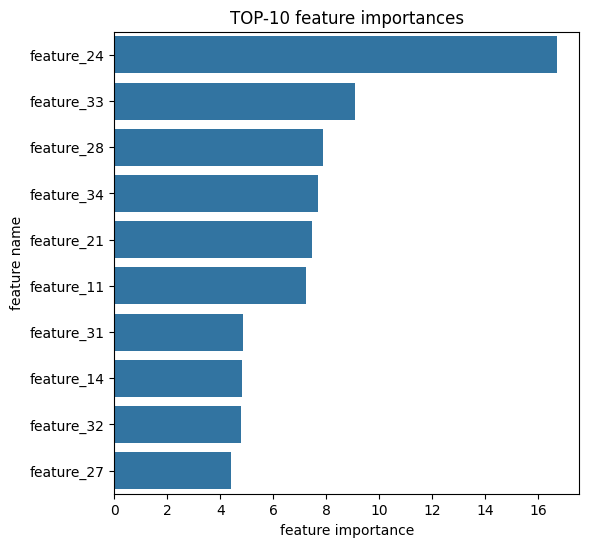

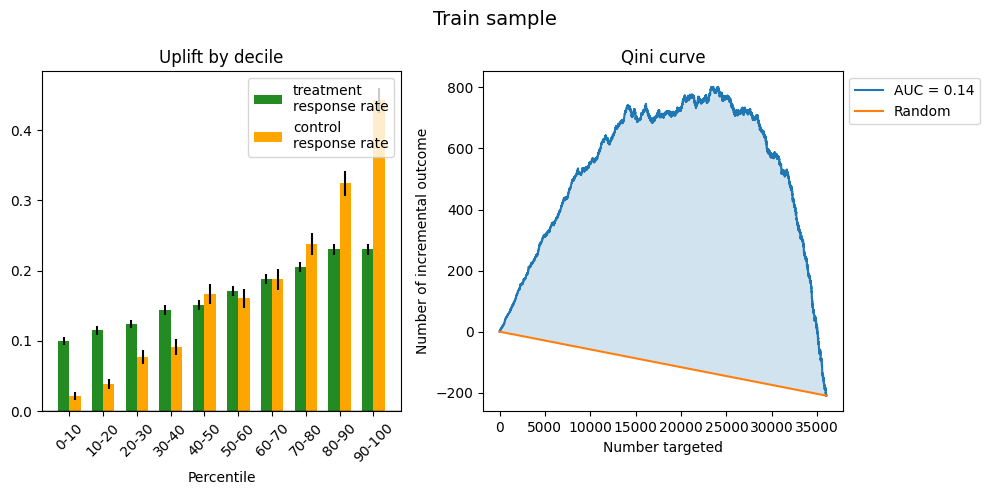

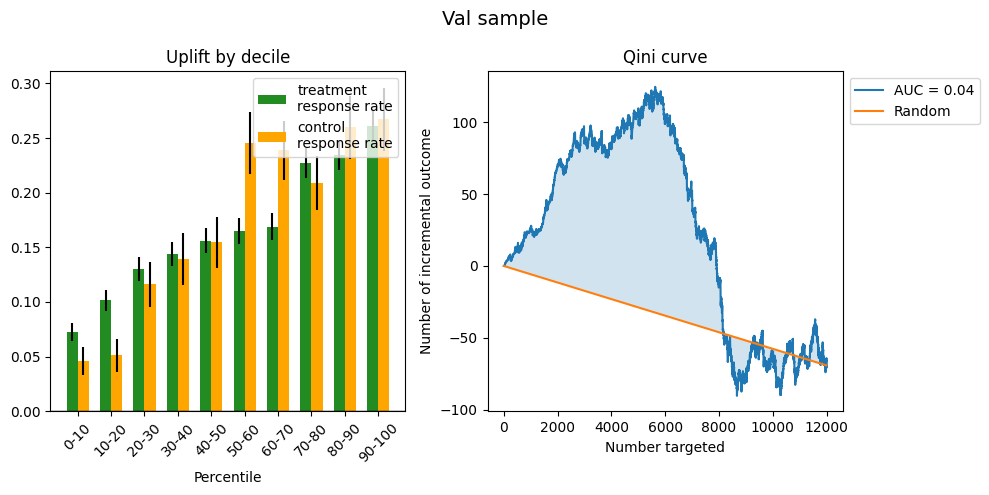

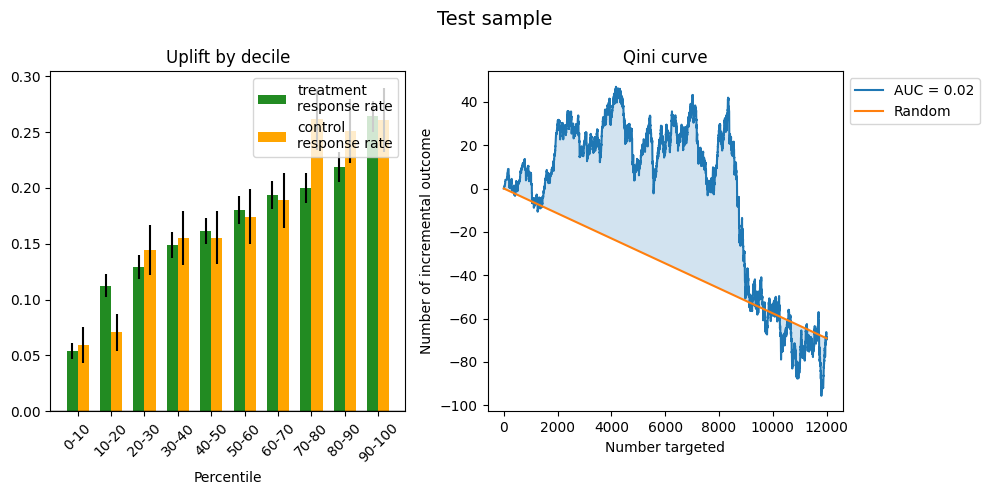

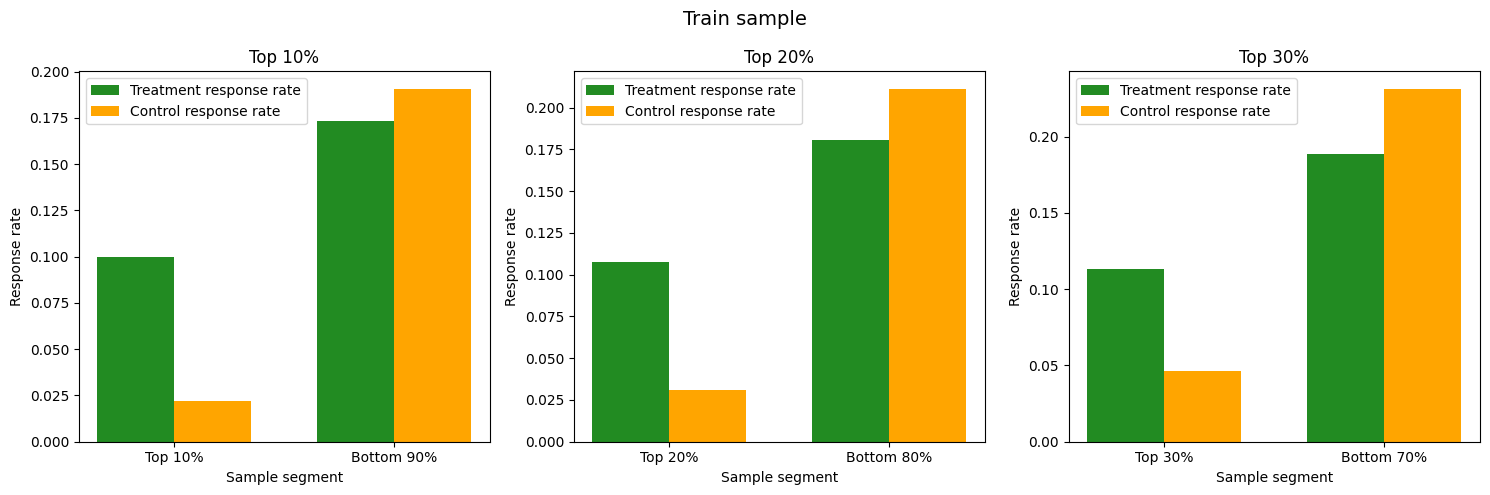

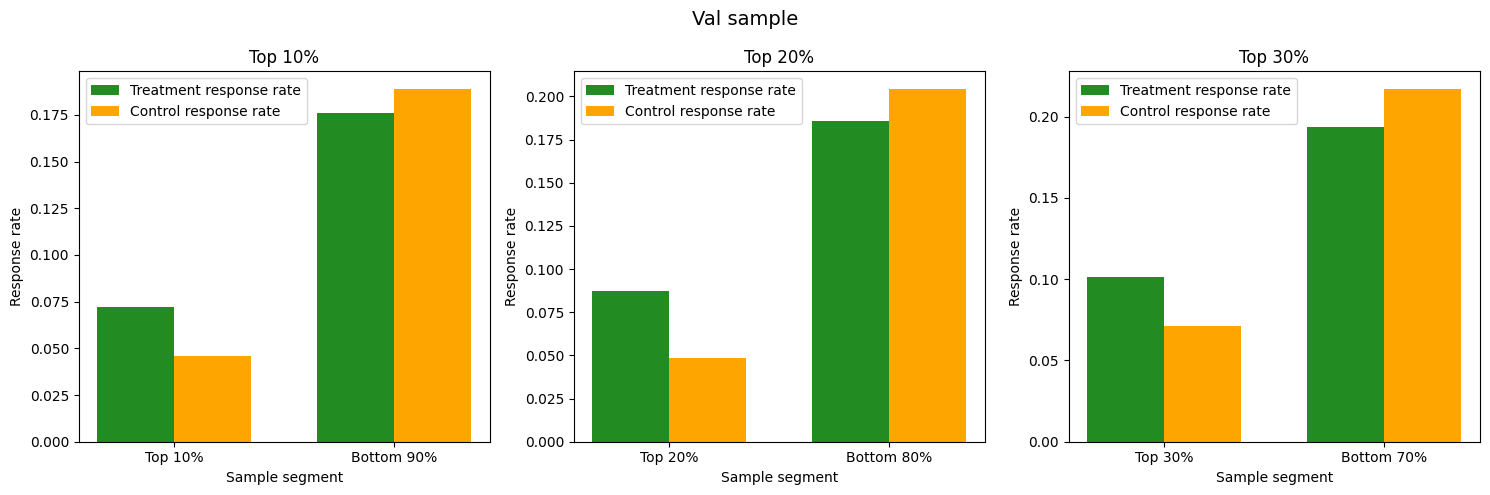

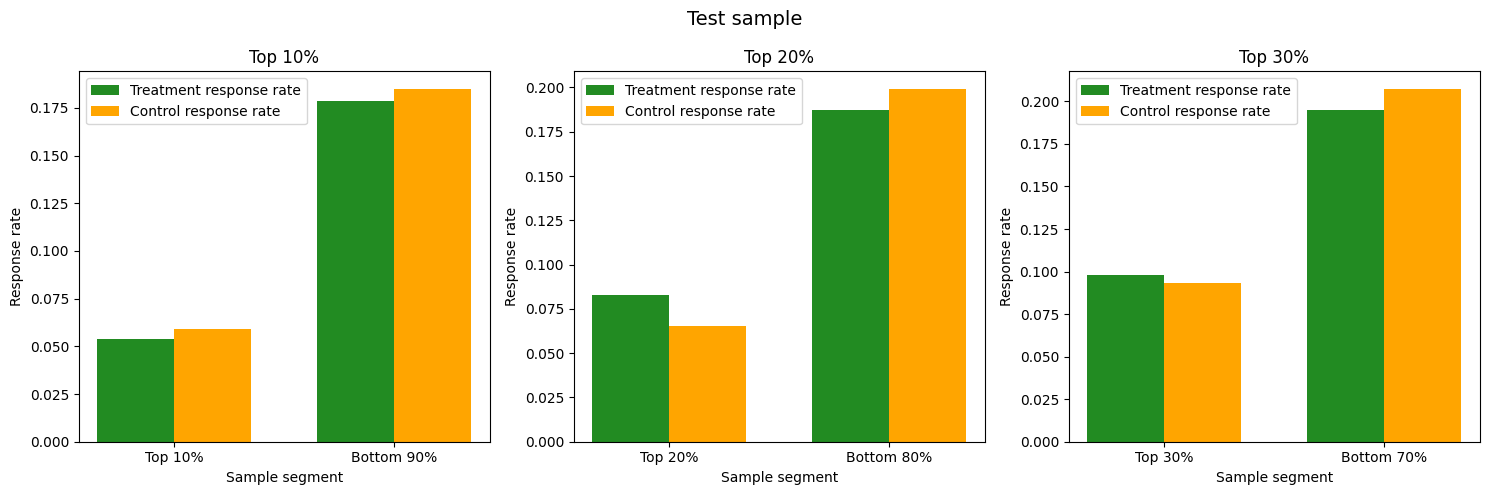

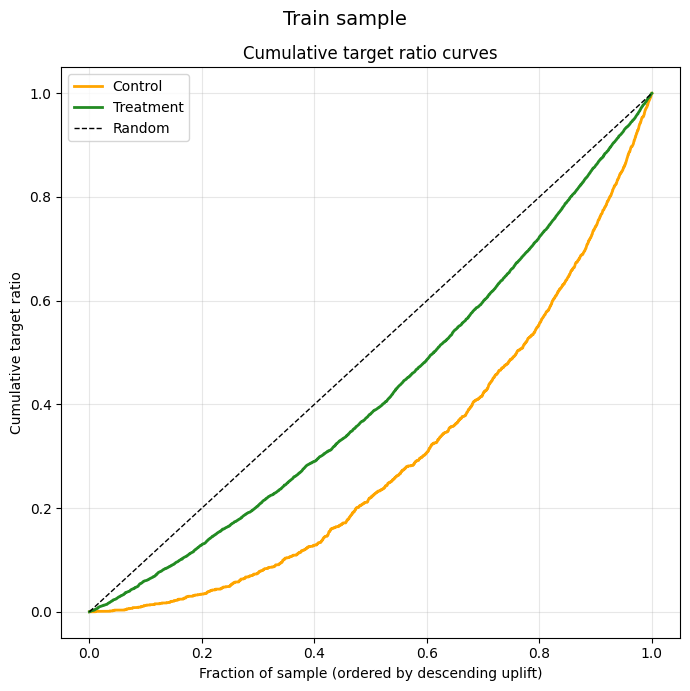

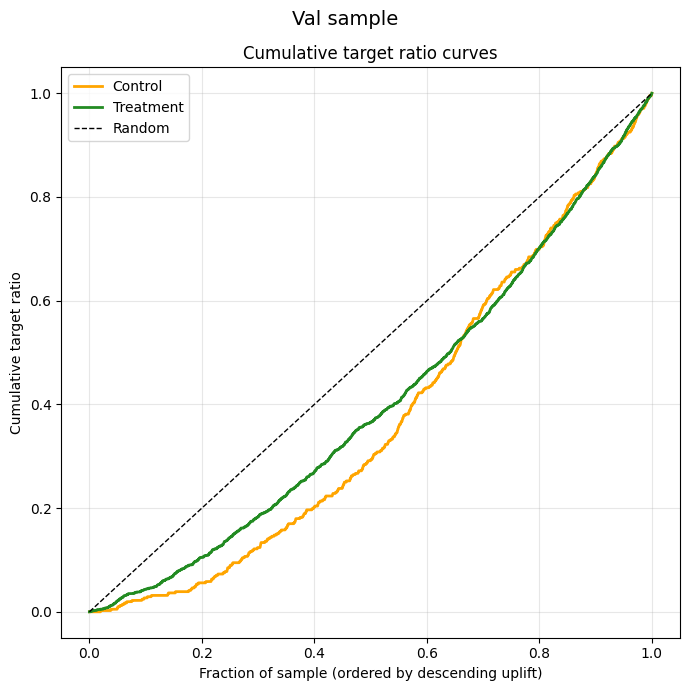

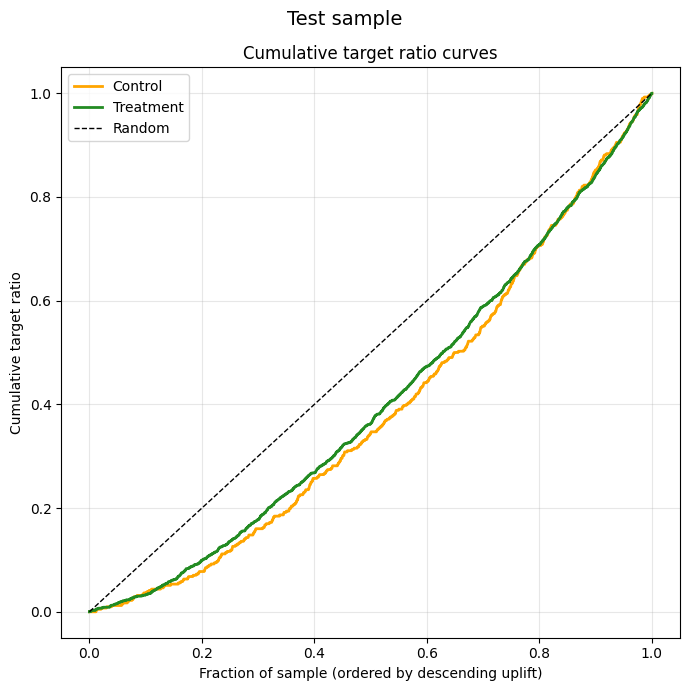

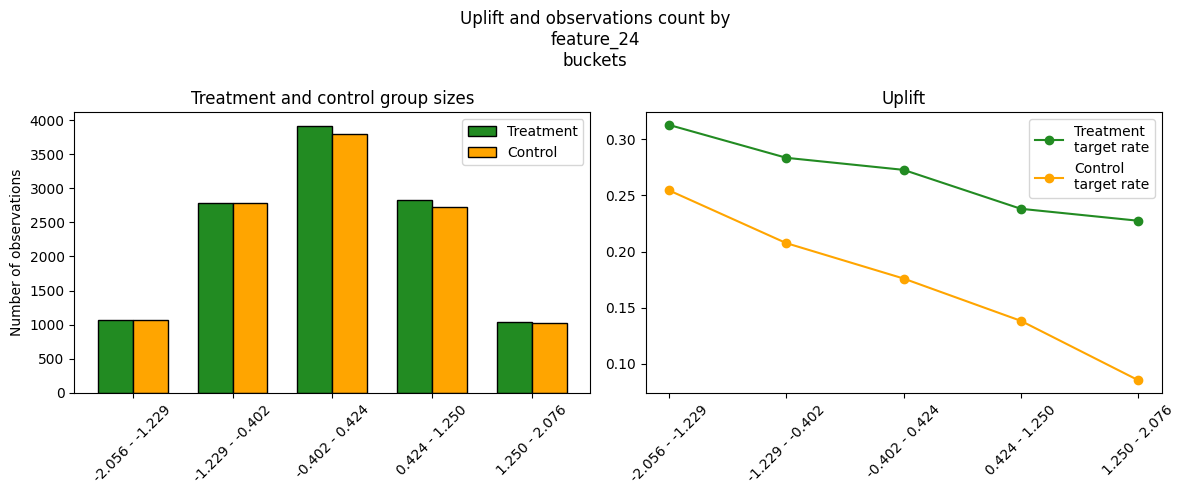

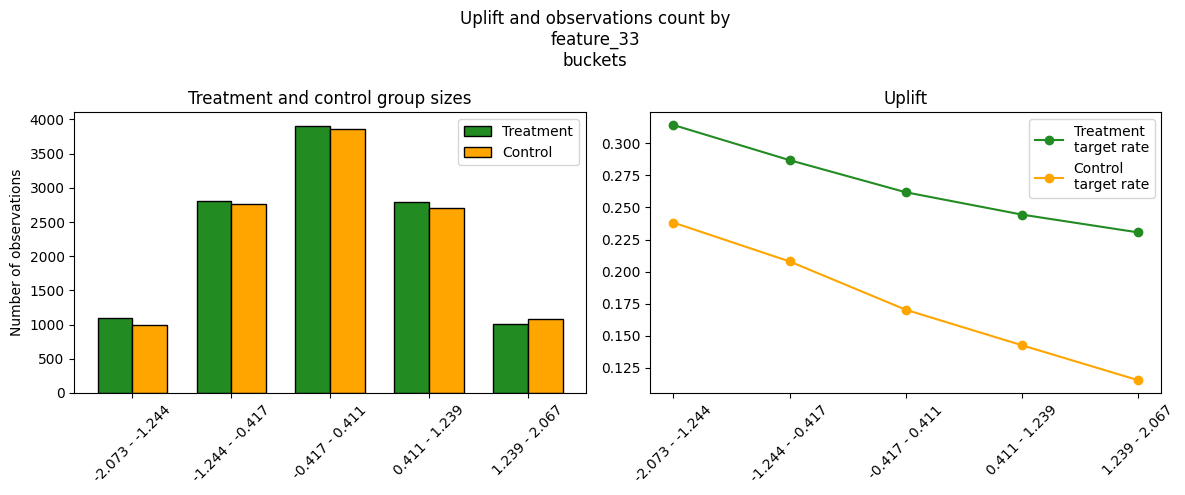

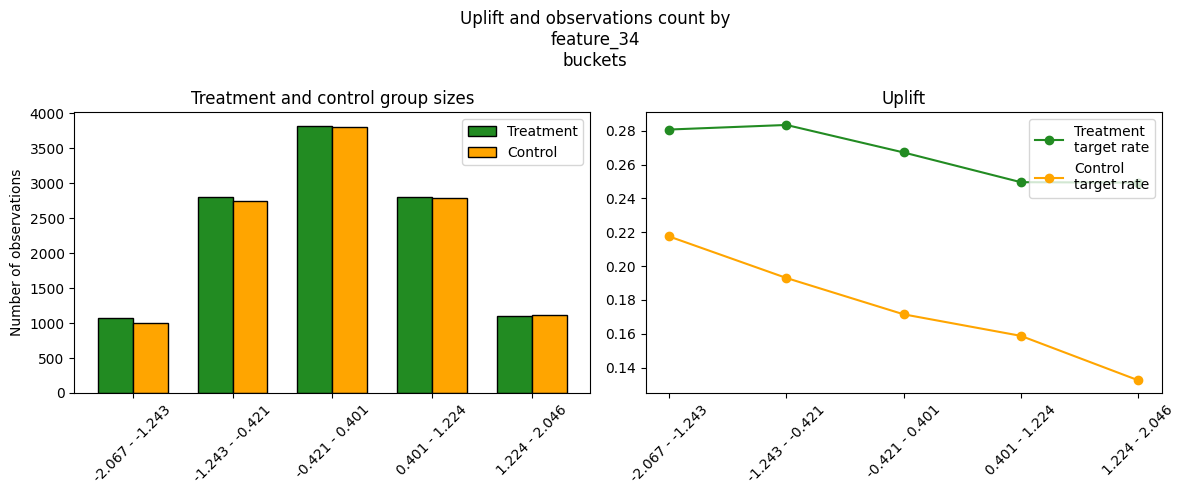

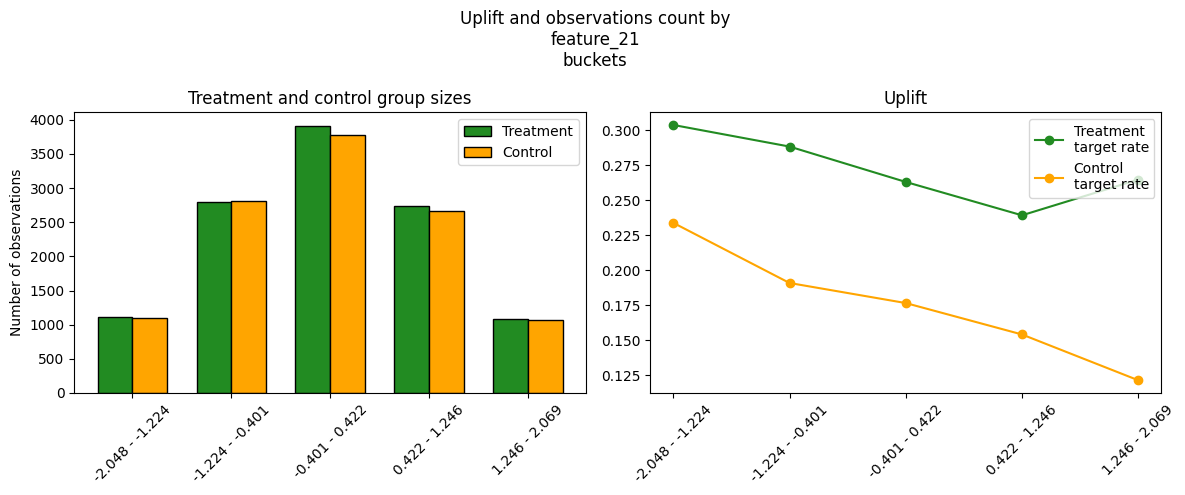

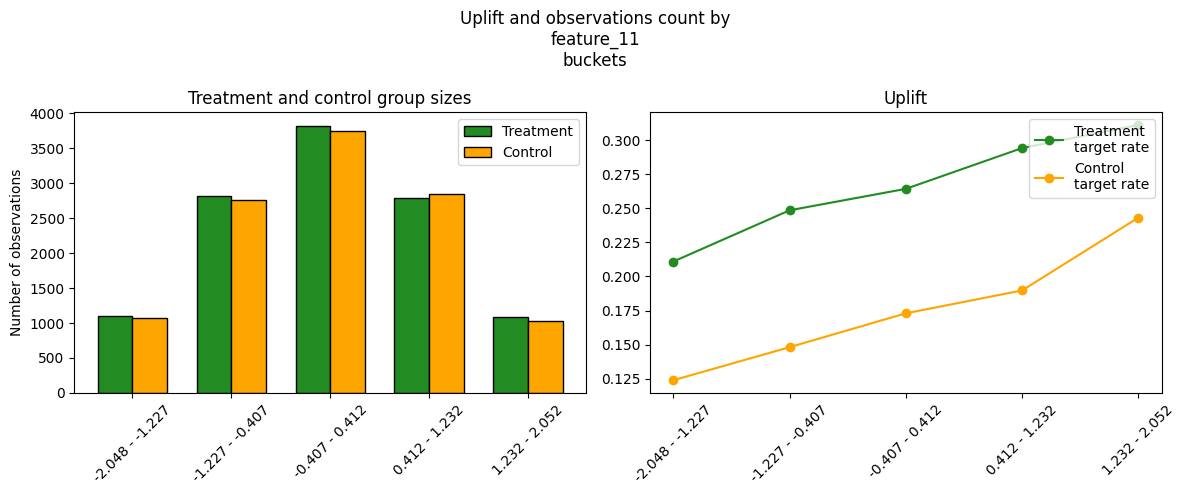

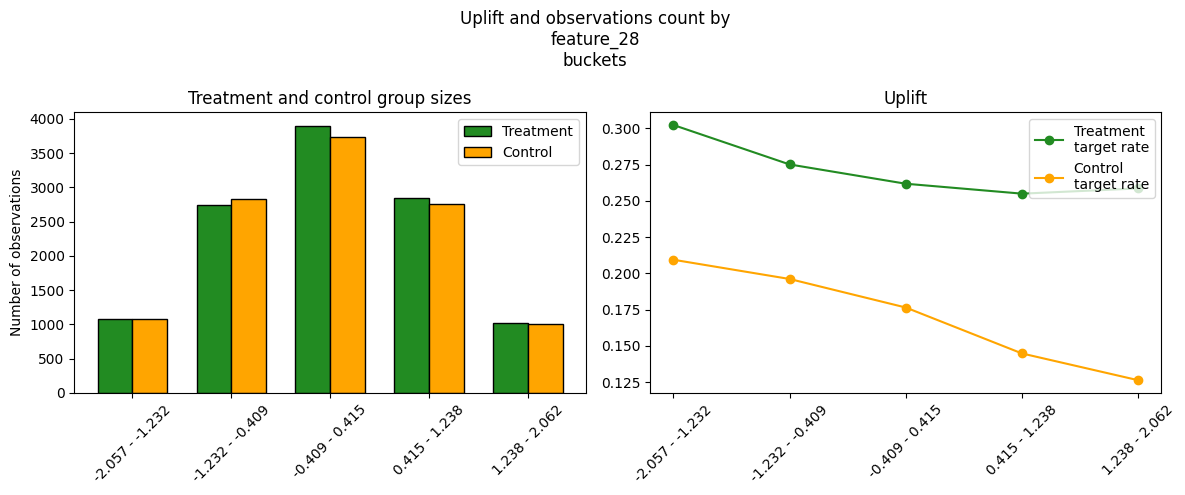

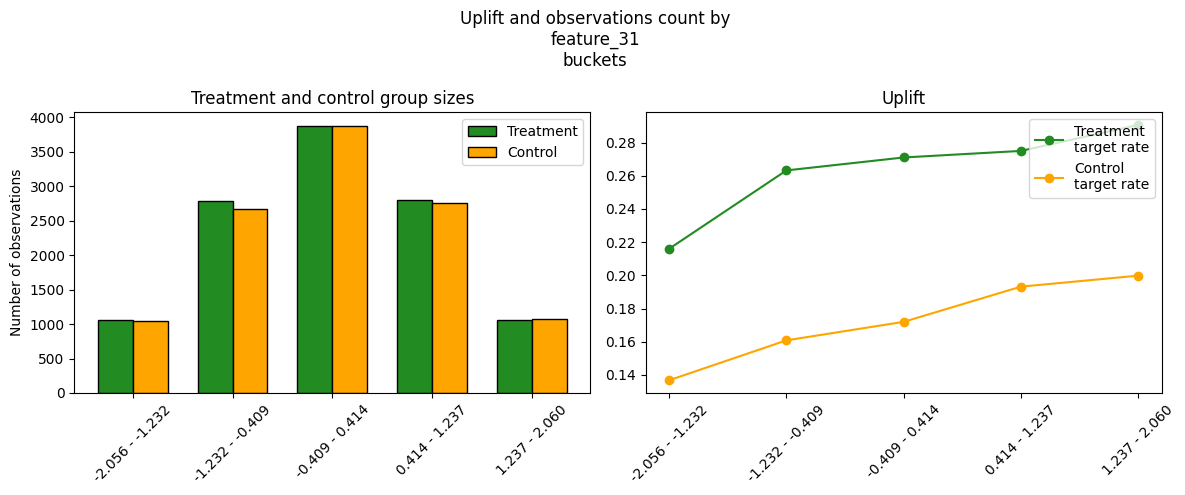

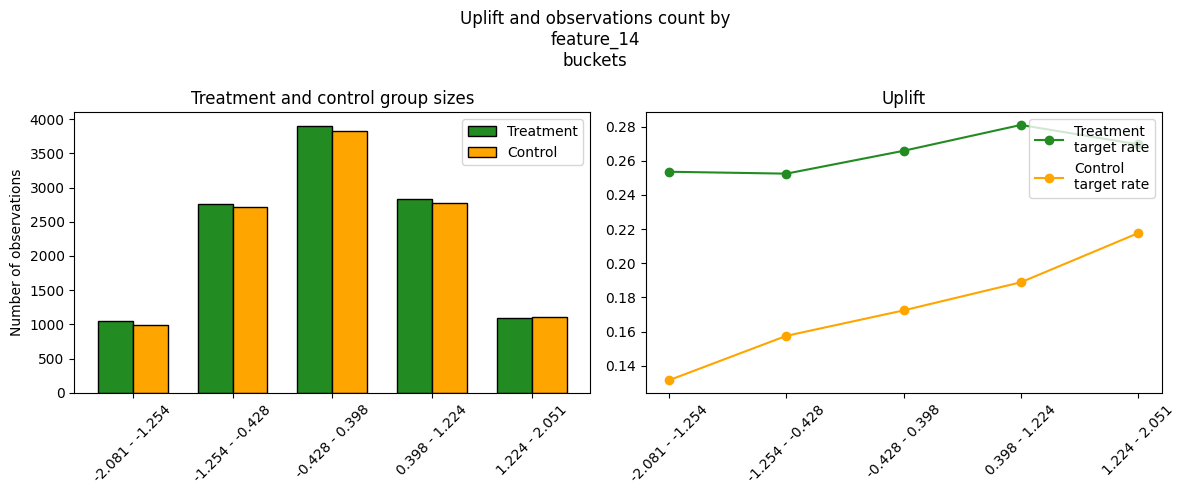

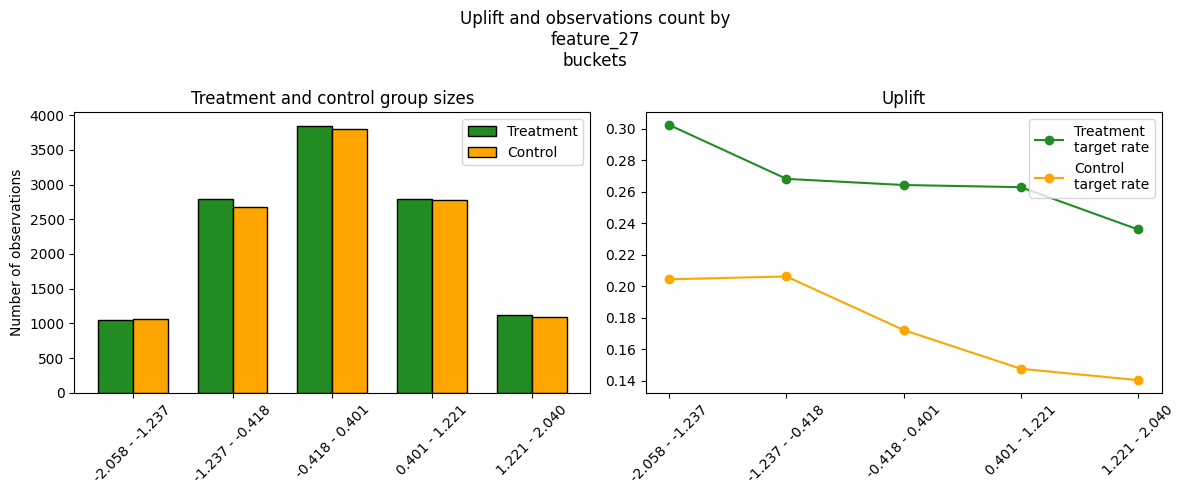

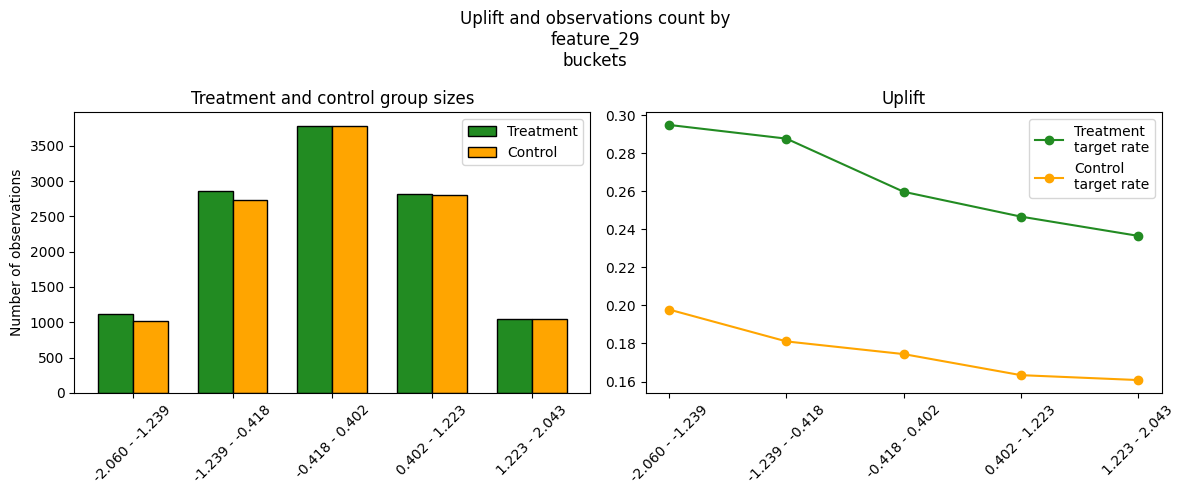

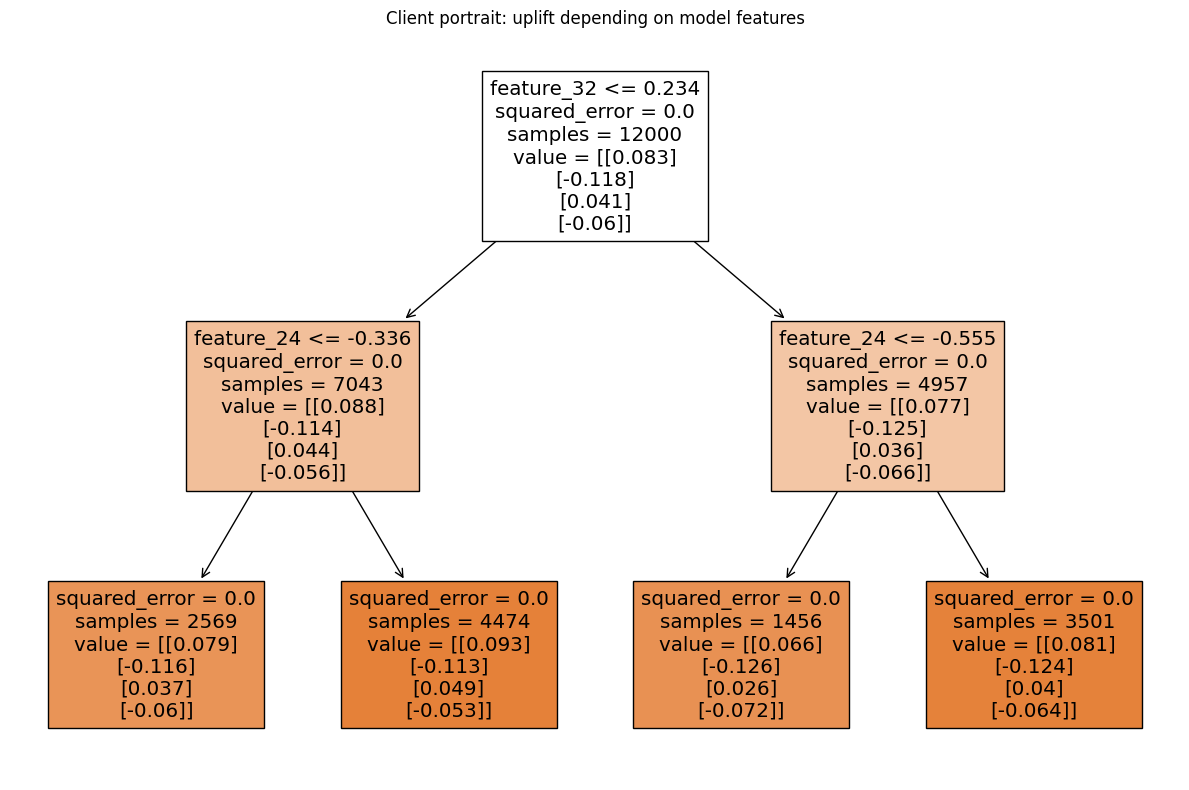

<Figure size 640x480 with 0 Axes>

In [6]:
preprocessor, model = pipeline.run(
    max_val_roc_auc_treatment = 0.6,
    early_stopping = 10,
    max_abs_feature_correlation = 0.9,
    n_features_candidates = 30,
    classes_for_train = [
        "BaseSClassifier",
        "BaseTClassifier",
        "BaseXClassifier",
        # "UpliftTreeClassifier",
        # "UpliftRandomForestClassifier",
    ],
    feature_nums = {
        "BaseSClassifier": [10, 20],
        "BaseTClassifier": [10, 20],
        "BaseXClassifier": [5, 10],
        # "UpliftTreeClassifier": [5],
        # "UpliftRandomForestClassifier": [5],
    },
    timeout_estimator = {
        "BaseSClassifier": 10,
        "BaseTClassifier": 10,
        "BaseXClassifier": 10,
        # "UpliftTreeClassifier": 10,
        # "UpliftRandomForestClassifier": 10,
    },
    opt_metric = 'qini_auc',
    training_mode="medium",
    n_uplift_bins=10,
)

<a id="inference"></a>

# 5. Inference model on some sample

[Contents](#home)

In [7]:
test_df = df[pipeline._df["segm"] == "test"]
test_df.shape

(12000, 54)

In [8]:
# from auf.pipeline.inference import UpliftInference
# mlflow_inference_pipeline = UpliftInference(run_id=pipeline._run_id)
# mlflow_scores = mlflow_inference_pipeline.predict(test_df)
# mlflow_scores.head(2)

In [9]:
from auf.pipeline.inference import UpliftInference
local_inference_pipeline = UpliftInference(preprocessor, model)
local_scores = local_inference_pipeline.predict(test_df)
local_scores.head(2)

,1,2,3,4
11,0.070079,-0.130841,0.029049,-0.068521
12,0.086417,-0.111857,0.034160,-0.055276


<a id="evaluate"></a>

# 6. Evaluate model on some sample 

[Contents](#home)

In [10]:
df2 = df[pipeline._df["segm"] == "test"].copy()
print(df2.shape)
df2.head(2)

(12000, 54)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,treatment,outcome,id,segm
11,0.086590,-0.155677,1.167782,0.254421,0.337603,-0.411877,-0.487606,-0.432558,0.394452,-0.420984,...,1.037540,-0.510016,-0.269875,-0.978764,-0.444293,0.377300,treatment_3,0,11,test
12,0.756989,-0.922165,0.869606,1.355638,0.413435,1.876796,-0.773789,-1.244655,-1.778720,1.496044,...,-0.245743,-0.272724,-2.696887,-0.054295,-0.230935,0.696206,treatment_2,0,12,test


,target_mean,target_sum,target_count
treatment,,,
0,0.173255,412,2378
1,0.166078,1598,9622


,5,10,15,20,25
qini_auc,0.020876,0.020876,0.020876,0.020876,0.020876
uplift@k,0.01013,-0.005009,0.006038,0.017772,0.008925
uplift_rel@k,0.23299,-0.084772,0.096898,0.272509,0.109515
treatment_ones_ratios@k,0.01627,0.033166,0.062578,0.100751,0.136421
control_ones_ratios@k,0.987864,0.968447,0.949029,0.927184,0.883495


,n_treatment,n_control,response_rate_treatment,response_rate_control,uplift,"rel_uplift, %"
percentile,,,,,,
0-10,980,220,0.054082,0.059091,-0.005009,-8.477237
10-20,960,240,0.112500,0.070833,0.041667,58.823529
20-30,951,249,0.129338,0.144578,-0.015241,-10.541535
30-40,974,226,0.148871,0.154867,-0.005997,-3.872103
40-50,968,232,0.161157,0.155172,0.005985,3.856749
50-60,959,241,0.180396,0.174274,0.006122,3.513084
60-70,951,249,0.193481,0.188755,0.004726,2.503524
70-80,936,264,0.199786,0.261364,-0.061577,-23.560015
80-90,973,227,0.218911,0.251101,-0.032191,-12.819819


,top,final_response_rate,top_target_ratio_treatment,top_target_ratio_control,top_response_rate_treatment,top_response_rate_control,bottom_response_rate_treatment,bottom_response_rate_control
0,5%,0.173538,0.016270,0.012136,0.053608,0.043478,0.172048,0.179850
1,10%,0.171812,0.033166,0.031553,0.054082,0.059091,0.178778,0.184893
2,15%,0.173090,0.062578,0.050971,0.068353,0.062315,0.183601,0.191573
3,20%,0.175931,0.100751,0.072816,0.082990,0.065217,0.187061,0.199166
4,25%,0.175204,0.136421,0.116505,0.090419,0.081494,0.191374,0.203466
5,30%,0.174588,0.177722,0.160194,0.098236,0.093089,0.195216,0.207310
6,35%,0.176922,0.227785,0.191748,0.107788,0.095990,0.197598,0.214148
7,40%,0.173712,0.268461,0.245146,0.110996,0.108021,0.203057,0.215523


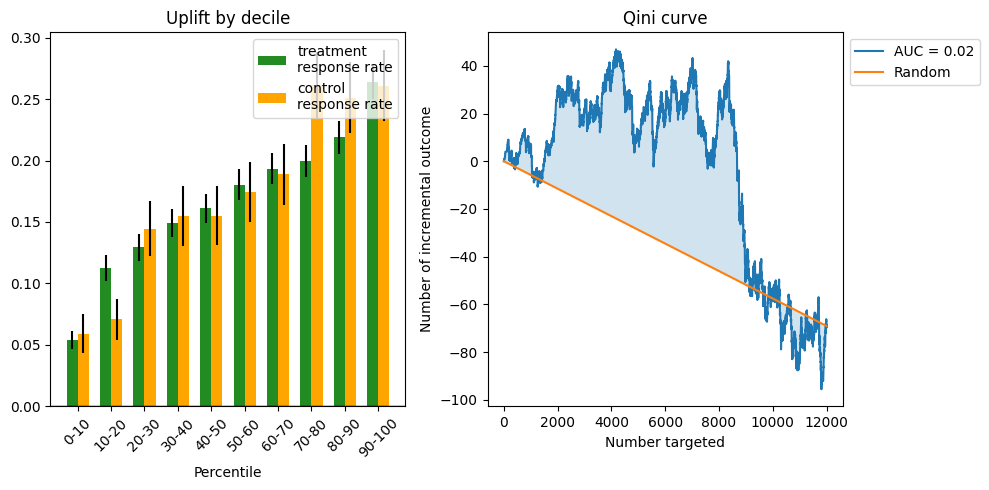

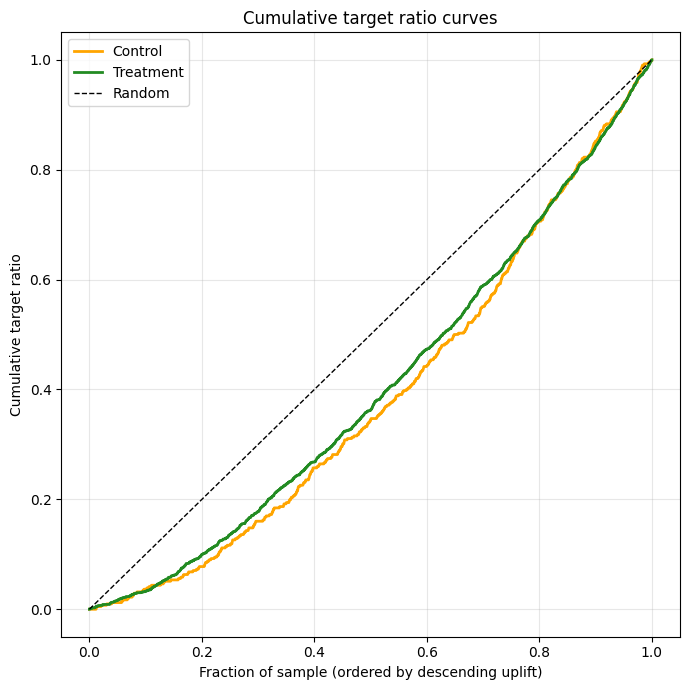

In [11]:
from auf.pipeline.evaluation import evaluate_model

evaluate_model(
    base_cols_mapper=base_cols_mapper,
    treatment_groups_mapper=treatment_groups_mapper,
    data=df2,
    preprocessor=preprocessor,
    model=model,
    evaluation_types = [
        'target_info',
        'metrics_table',
        'buckets_table',
        'tops_table',
        "buckets_qini_plots",
        "target_ratios_plots",
    ],
    # n_uplift_bins: int = 10,
)